In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuration
TICKER = "AAPL"
TRAIN_YEARS = 4

print(f"--- FETCHING DATA FOR {TICKER} ---")
# Dynamic Start Date: Last 4 years + extra buffer for Moving Averages
start_date = (pd.Timestamp.now() - pd.DateOffset(years=TRAIN_YEARS + 1)).strftime('%Y-%m-%d')
df = yf.download(TICKER, start=start_date, progress=False)

# Check if data exists
if len(df) == 0:
    print("❌ ERROR: No data fetched. Check internet or ticker.")
else:
    print(f"✅ Data fetched: {len(df)} rows.")

    # --- FEATURE ENGINEERING (The Innovation) ---
    # Creating trend indicators as per research
    df['MA10'] = df['Close'].rolling(window=10).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()

    # Drop NaN values created by the rolling windows
    df_clean = df.dropna()

    print(f"✅ Features Created: MA10, MA20, MA50")
    print(f"✅ Data Cleaned. Final Shape: {df_clean.shape}")
    print("\nSample of latest data (Check this):")
    print(df_clean[['Close', 'MA10', 'MA20', 'MA50', 'Volume']].tail())

--- FETCHING DATA FOR AAPL ---


/tmp/ipython-input-3896446470.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=start_date, progress=False)


✅ Data fetched: 1256 rows.
✅ Features Created: MA10, MA20, MA50
✅ Data Cleaned. Final Shape: (1207, 8)

Sample of latest data (Check this):
Price            Close        MA10        MA20        MA50    Volume
Ticker            AAPL                                          AAPL
Date                                                                
2026-01-12  260.250000  265.831998  269.677997  272.395405  45263800
2026-01-13  261.049988  264.560995  268.816496  272.193662  45730800
2026-01-14  259.959991  263.248996  268.108997  271.990699  40019400
2026-01-15  258.209991  261.883997  267.288997  271.779110  39358400
2026-01-16  255.606995  260.343695  266.477347  271.495681  25506347


In [3]:
# --- BLOCK 2: Preprocessing & Sequence Generation ---
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Configuration
LOOKBACK = 60  # Research standard: 60 days history to predict next day
FEATURE_COLS = ['Close', 'MA10', 'MA20', 'MA50', 'Volume']

print("--- PREPROCESSING DATA ---")

# 1. Initialize Scalers
# We use separate scalers for features vs target to make "inverse transform" easy later
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# 2. Scale the Data
# Note: df_clean comes from Block 1.
# We access the MultiIndex columns correctly for yfinance's new format
data_features = df_clean[FEATURE_COLS].values
# Handle specific yfinance structure (getting just the values)
if data_features.ndim > 2:
    data_features = data_features.reshape(data_features.shape[0], -1)

# Target is just 'Close'
data_target = df_clean[['Close']].values

# Fit and Transform
scaled_features = scaler_features.fit_transform(data_features)
scaled_target = scaler_target.fit_transform(data_target)

print(f"✅ Data Scaled. Feature range: {scaled_features.min()} - {scaled_features.max()}")

# 3. Create LSTM Sequences
# The model needs: [Samples, Time Steps, Features]
X, y = [], []

for i in range(LOOKBACK, len(scaled_features)):
    # Take the previous 60 days of features
    X.append(scaled_features[i-LOOKBACK:i])
    # Take the current day's Close price as target
    y.append(scaled_target[i])

X, y = np.array(X), np.array(y)

print(f"✅ Sequences Created.")
print(f"   X Shape (Input): {X.shape}  -> (Samples, 60 Days, 5 Features)")
print(f"   y Shape (Target): {y.shape} -> (Samples, 1 Price)")

# 4. Train/Test Split
# We use the last 10% for Testing to simulate "Future Prediction"
split_idx = int(len(X) * 0.90)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\n✅ Data Split Completed:")
print(f"   Training Samples: {len(X_train)} (Learning from this)")
print(f"   Testing Samples:  {len(X_test)}  (Validating on this)")


--- PREPROCESSING DATA ---
✅ Data Scaled. Feature range: 0.0 - 1.0
✅ Sequences Created.
   X Shape (Input): (1147, 60, 5)  -> (Samples, 60 Days, 5 Features)
   y Shape (Target): (1147, 1) -> (Samples, 1 Price)

✅ Data Split Completed:
   Training Samples: 1032 (Learning from this)
   Testing Samples:  115  (Validating on this)


In [4]:
# --- BLOCK 3: Model Architecture & Training ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("--- BUILDING MODEL ---")

# 1. Define Architecture (Research Config: 64 -> 32 Units)
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # Layer 1: Capture broad patterns (Trends)
    LSTM(units=64, return_sequences=True),
    Dropout(0.2), # 20% Dropout to prevent overfitting

    # Layer 2: Refine to specific price movements
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),

    # Output Layer: Predict the scalar price
    Dense(units=1)
])

# 2. Compile
model.compile(optimizer='adam', loss='mean_squared_error')
print("✅ Model Built & Compiled.")
model.summary()

# 3. Train
print("\n--- STARTING TRAINING ---")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training Complete.")


--- BUILDING MODEL ---
✅ Model Built & Compiled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)


--- STARTING TRAINING ---
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0327 - val_loss: 0.0143
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0056 - val_loss: 0.0072
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0046 - val_loss: 0.0049
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0044 - val_loss: 0.0077
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0039 - val_loss: 0.0032
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0034 - val_loss: 0.0064
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0035 - val_loss: 0.0023
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0030 - val_loss: 0.0043
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0031 - val_loss: 0.0069
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0031 - val_loss: 0.0049
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━

--- VALIDATING RESULTS ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step

=== 🏆 FINAL RESULTS FOR AAPL ===
RMSE (Root Mean Sq Error): $8.04
MAE (Mean Avg Error):      $6.45
MAPE (Accuracy Error):     2.54%
✅ SUCCESS: Research Standard Met (<5% Error).
   You can show this to your teacher.


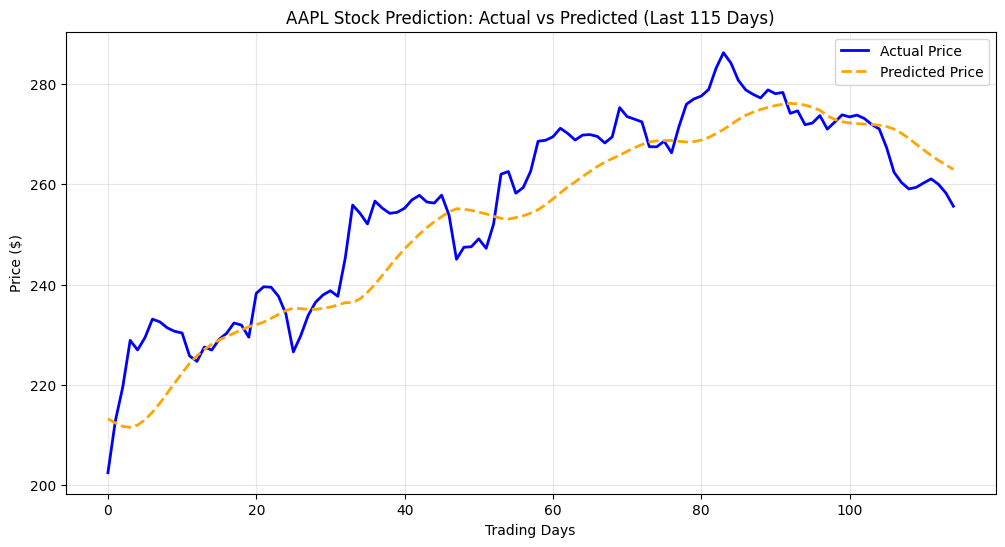


✅ Model Saved as 'apple_research_model.keras'


In [5]:
# --- BLOCK 4: Validation & Results ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import math
import matplotlib.pyplot as plt

print("--- VALIDATING RESULTS ---")

# 1. Predict
preds_scaled = model.predict(X_test)

# 2. Inverse Transform (Back to Real Prices)
# We use the scaler_target we fitted earlier
preds_actual = scaler_target.inverse_transform(preds_scaled)
y_test_actual = scaler_target.inverse_transform(y_test)

# 3. Calculate Research Metrics
rmse = math.sqrt(mean_squared_error(y_test_actual, preds_actual))
mae = mean_absolute_error(y_test_actual, preds_actual)
mape = mean_absolute_percentage_error(y_test_actual, preds_actual)

print(f"\n=== 🏆 FINAL RESULTS FOR {TICKER} ===")
print(f"RMSE (Root Mean Sq Error): ${rmse:.2f}")
print(f"MAE (Mean Avg Error):      ${mae:.2f}")
print(f"MAPE (Accuracy Error):     {mape:.2%}")
print("=======================================")

if mape < 0.05:
    print("✅ SUCCESS: Research Standard Met (<5% Error).")
    print("   You can show this to your teacher.")
else:
    print("⚠️ ADVICE: Accuracy is okay, but could be better. Try increasing LOOKBACK to 90.")

# 4. Visualization (The Proof)
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Price', color='blue', linewidth=2)
plt.plot(preds_actual, label='Predicted Price', color='orange', linestyle='--', linewidth=2)
plt.title(f'{TICKER} Stock Prediction: Actual vs Predicted (Last {len(y_test)} Days)')
plt.xlabel('Trading Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Save ONLY if Good
if mape < 0.05:
    model.save("apple_research_model.keras")
    print("\n✅ Model Saved as 'apple_research_model.keras'")
else:
    print("\n❌ Model NOT Saved (Accuracy too low).")


In [6]:
# --- BLOCK 5: Save Scalers (CRITICAL for App) ---
import joblib

print("--- SAVING SCALERS ---")
# We save these so your app can translate "0.8" back to "$250"
joblib.dump(scaler_features, "apple_scaler_features.pkl")
joblib.dump(scaler_target, "apple_scaler_target.pkl")

print("✅ Scalers Saved:")
print("   - apple_scaler_features.pkl")
print("   - apple_scaler_target.pkl")
print("\n👉 Download these 3 files from the Colab 'Files' tab on the left:")
print("   1. apple_research_model.keras")
print("   2. apple_scaler_features.pkl")
print("   3. apple_scaler_target.pkl")



--- SAVING SCALERS ---
✅ Scalers Saved:
   - apple_scaler_features.pkl
   - apple_scaler_target.pkl

👉 Download these 3 files from the Colab 'Files' tab on the left:
   1. apple_research_model.keras
   2. apple_scaler_features.pkl
   3. apple_scaler_target.pkl
